In [84]:
import pandas as pd 
pd.set_option('display.max_columns', None)

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

**5 W**
- *who* - the customers
- *what* - churn rate rose from 18% to 27%, costing an estimated of 2.1M doller
- *when* - past quater
- *where*  - 
- *why* - 
- *how* - identify high risk customers

In [85]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# -------------------------------
# 0. DATA CLEANING (CRITICAL FIX)
# -------------------------------

# Remove leading/trailing spaces
# df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Convert TotalCharges to numeric (this is the main issue)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows where conversion failed
df = df.dropna()

# Drop customerID (not useful)
df = df.drop(columns=['customerID'])

# -------------------------------
# 1. Label Encoding (Target)
# -------------------------------
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])

# -------------------------------
# 2. Define Columns
# -------------------------------
ordinal_cols = ['Contract']

nominal_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
    'PaymentMethod'
]

ordinal_order = [['Month-to-month', 'One year', 'Two year']]

# -------------------------------
# 4. Column Transformer & apply ct.fit_transform()
# -------------------------------
ct = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(categories=ordinal_order), ordinal_cols),
        ('onehot', OneHotEncoder(drop='first', sparse_output=False), nominal_cols)
    ],
    remainder='passthrough'
)
df_transformed = ct.fit_transform(df)

# -------------------------------
# 6. Convert to DataFrame
# -------------------------------
encoded_columns = ct.get_feature_names_out()
df_final = pd.DataFrame(df_transformed, columns=encoded_columns)
df_final = df_final.apply(pd.to_numeric)
import plotly.express as px
px.imshow(df_final.corr())

# 📊 Data Preprocessing Metadata & Transformation Summary

## 🧾 Dataset Overview

* Dataset: Customer Churn Dataset
* Total Records (after cleaning): `{{df.shape[0]}}`
* Total Features (after encoding): `{{df_final.shape[1]}}`

---

## 🧹 Data Cleaning Steps

### 1. Handling Missing & Invalid Values

* Column **`TotalCharges`** contained non-numeric values (e.g., blank spaces `" "`).
* Converted to numeric using:

  ```python
  pd.to_numeric(errors='coerce')
  ```
* Rows with invalid values were removed using:

  ```python
  df.dropna()
  ```

---

### 2. Dropping Irrelevant Features

* Removed:

  * `customerID` → Unique identifier, not useful for modeling

---

## 🎯 Target Variable Transformation

### Label Encoding

* Column: `Churn`
* Transformation:

  * `Yes → 1`
  * `No → 0`
* Method used:

  ```python
  LabelEncoder()
  ```

---

## 🔢 Feature Encoding Strategy

### 1. Ordinal Encoding (Order Matters)

* Column: `Contract`

* Defined Order:

  * Month-to-month → 0
  * One year → 1
  * Two year → 2

* Method:

  ```python
  OrdinalEncoder(categories=[['Month-to-month', 'One year', 'Two year']])
  ```

---

### 2. One-Hot Encoding (Nominal Data)

* Applied to:

  * gender, Partner, Dependents, PhoneService
  * MultipleLines, InternetService
  * OnlineSecurity, OnlineBackup, DeviceProtection
  * TechSupport, StreamingTV, StreamingMovies
  * PaperlessBilling, PaymentMethod

* Strategy:

  * Used `drop='first'` to avoid dummy variable trap

* Method:

  ```python
  OneHotEncoder(drop='first')
  ```

---

## ⚙️ Transformation Pipeline

* Used **ColumnTransformer** to apply:

  * Ordinal Encoding → `Contract`
  * One-Hot Encoding → Nominal Columns
  * Remaining columns passed through unchanged

---

## 📦 Output Dataset (`df_final`)

* All features converted to numeric:

  ```python
  df_final = df_final.apply(pd.to_numeric)
  ```

* Final dataset contains:

  * Encoded categorical features
  * Numerical features (tenure, MonthlyCharges, TotalCharges)
  * Target variable (`Churn`)

---

## 📈 Correlation Analysis

* Correlation matrix generated using:

  ```python
  df_final.corr()
  ```

* Visualized with:

  ```python
  plotly.express.imshow()
  ```

---

## 🧠 Key Notes

* ✔️ Ensured no non-numeric values remain
* ✔️ Avoided multicollinearity using `drop='first'`
* ✔️ Maintained ordinal relationships where necessary
* ✔️ Pipeline is scalable for ML models

---


IQR Outliers count per column:
 ordinal__Contract                                   0
onehot__gender_Male                                 0
onehot__Partner_Yes                                 0
onehot__Dependents_Yes                              0
onehot__PhoneService_Yes                          680
onehot__MultipleLines_No phone service            680
onehot__MultipleLines_Yes                           0
onehot__InternetService_Fiber optic                 0
onehot__InternetService_No                       1520
onehot__OnlineSecurity_No internet service       1520
onehot__OnlineSecurity_Yes                          0
onehot__OnlineBackup_No internet service         1520
onehot__OnlineBackup_Yes                            0
onehot__DeviceProtection_No internet service     1520
onehot__DeviceProtection_Yes                        0
onehot__TechSupport_No internet service          1520
onehot__TechSupport_Yes                             0
onehot__StreamingTV_No internet service          1

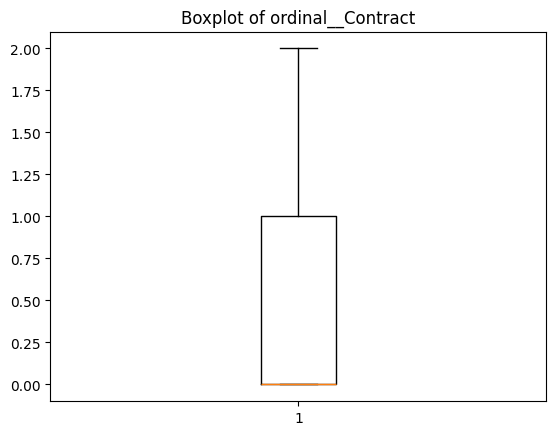

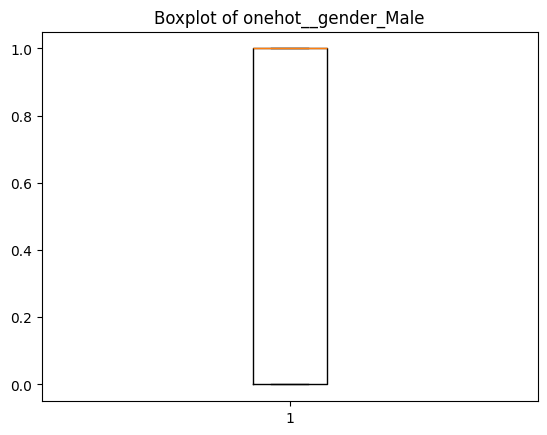

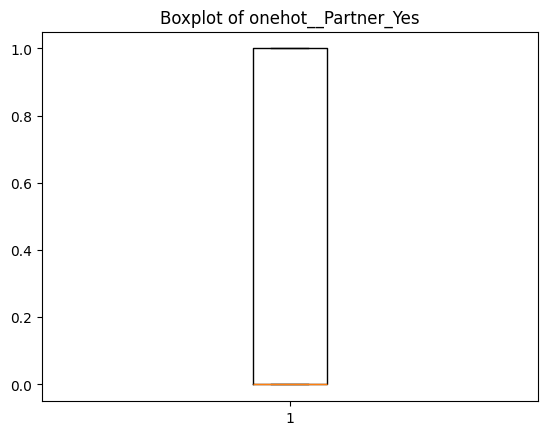

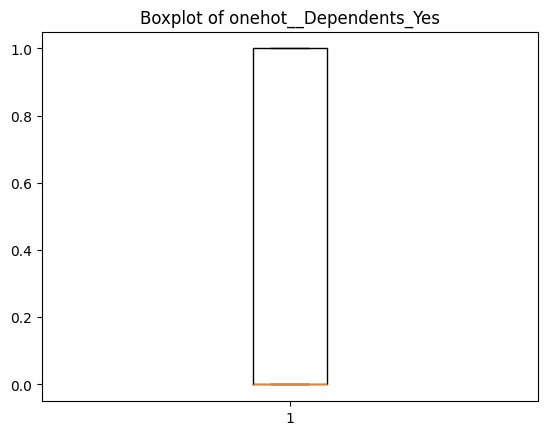

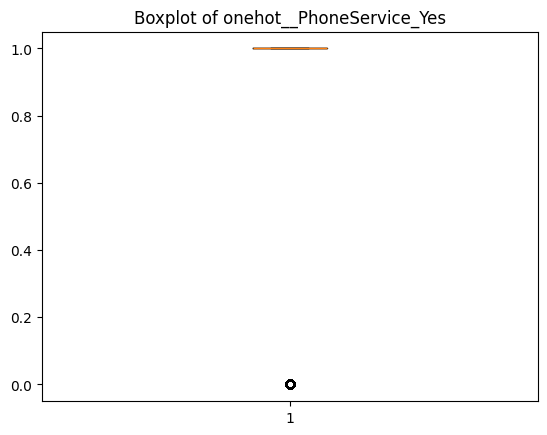

In [92]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# -------------------------------
# Select only numerical columns
# -------------------------------
numeric_cols = df_final.select_dtypes(include=['float64', 'int64']).columns

# -------------------------------
# 1. IQR METHOD
# -------------------------------
Q1 = df_final[numeric_cols].quantile(0.25)
Q3 = df_final[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_outliers = ((df_final[numeric_cols] < lower_bound) | 
                (df_final[numeric_cols] > upper_bound))

print("IQR Outliers count per column:\n", iqr_outliers.sum())

# Optional: Remove outliers
df_iqr_cleaned = df_final[~iqr_outliers.any(axis=1)]

# -------------------------------
# 2. Z-SCORE METHOD
# -------------------------------
z_scores = np.abs(stats.zscore(df_final[numeric_cols]))

z_outliers = (z_scores > 3)

print("\nZ-score Outliers count per column:\n", z_outliers.sum(axis=0))

# Optional: Remove outliers
df_z_cleaned = df_final[(z_scores < 3).all(axis=1)]

# -------------------------------
# 3. BOX PLOT (Visualization)
# -------------------------------
for col in numeric_cols[:5]:  # limiting to first 5 columns for clarity
    plt.figure()
    plt.boxplot(df_final[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [88]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 30 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   ordinal__Contract                              7032 non-null   float64
 1   onehot__gender_Male                            7032 non-null   float64
 2   onehot__Partner_Yes                            7032 non-null   float64
 3   onehot__Dependents_Yes                         7032 non-null   float64
 4   onehot__PhoneService_Yes                       7032 non-null   float64
 5   onehot__MultipleLines_No phone service         7032 non-null   float64
 6   onehot__MultipleLines_Yes                      7032 non-null   float64
 7   onehot__InternetService_Fiber optic            7032 non-null   float64
 8   onehot__InternetService_No                     7032 non-null   float64
 9   onehot__OnlineSecurity_No internet service     7032 

In [91]:
df_final.isna().sum()

ordinal__Contract                                0
onehot__gender_Male                              0
onehot__Partner_Yes                              0
onehot__Dependents_Yes                           0
onehot__PhoneService_Yes                         0
onehot__MultipleLines_No phone service           0
onehot__MultipleLines_Yes                        0
onehot__InternetService_Fiber optic              0
onehot__InternetService_No                       0
onehot__OnlineSecurity_No internet service       0
onehot__OnlineSecurity_Yes                       0
onehot__OnlineBackup_No internet service         0
onehot__OnlineBackup_Yes                         0
onehot__DeviceProtection_No internet service     0
onehot__DeviceProtection_Yes                     0
onehot__TechSupport_No internet service          0
onehot__TechSupport_Yes                          0
onehot__StreamingTV_No internet service          0
onehot__StreamingTV_Yes                          0
onehot__StreamingMovies_No inte

In [93]:
df_final

,ordinal__Contract,onehot__gender_Male,onehot__Partner_Yes,onehot__Dependents_Yes,onehot__PhoneService_Yes,onehot__MultipleLines_No phone service,onehot__MultipleLines_Yes,onehot__InternetService_Fiber optic,onehot__InternetService_No,onehot__OnlineSecurity_No internet service,onehot__OnlineSecurity_Yes,onehot__OnlineBackup_No internet service,onehot__OnlineBackup_Yes,onehot__DeviceProtection_No internet service,onehot__DeviceProtection_Yes,onehot__TechSupport_No internet service,onehot__TechSupport_Yes,onehot__StreamingTV_No internet service,onehot__StreamingTV_Yes,onehot__StreamingMovies_No internet service,onehot__StreamingMovies_Yes,onehot__PaperlessBilling_Yes,onehot__PaymentMethod_Credit card (automatic),onehot__PaymentMethod_Electronic check,onehot__PaymentMethod_Mailed check,remainder__SeniorCitizen,remainder__tenure,remainder__MonthlyCharges,remainder__TotalCharges,remainder__Churn
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,29.85,29.85,0.0
1,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,34.0,56.95,1889.50,0.0
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,53.85,108.15,1.0
3,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0,42.30,1840.75,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,70.70,151.65,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,24.0,84.80,1990.50,0.0
7028,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,72.0,103.20,7362.90,0.0
7029,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,11.0,29.60,346.45,0.0
7030,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,4.0,74.40,306.60,1.0
